# Klasifikasi Prioritas Bantuan Traktor - Perbandingan Seleksi Fitur

Notebook ini membandingkan beberapa **pilihan fitur** secara adil (LR, RF, XGBoost), merangkumnya dalam satu tabel, lalu memilih model produksi. Pendekatan terbaik kita - **Min-max composite** - diletakkan terakhir, lengkap dengan cara memperolehnya.

**Catatan metodologi.** Data ini **bersifat panel** (38 kabupaten x 6 tahun, 2020-2025). Karena itu kita tidak memakai pembagian acak biasa (yang bisa menyebabkan kebocoran data / data leakage), melainkan cross-validation **per kabupaten**. Penjelasan lengkapnya ada di Bagian 4.

# 1. Setup & Import

In [3]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedGroupKFold, GroupShuffleSplit, cross_validate, cross_val_score, cross_val_predict, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.metrics import f1_score, classification_report
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 60)

# 2. Memuat Data & Menyiapkan Fitur

In [4]:
DATA_PATH = "./dataset/r2dataset_compatible.csv"
df = pd.read_csv(DATA_PATH)
TARGET = "rekomendasi_prioritas_bantuan"
URUTAN = ["Rendah", "Sedang", "Tinggi"]
y = df[TARGET].map({"Rendah": 0, "Sedang": 1, "Tinggi": 2})
groups = df["kabupaten_kota"]
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

df_eng = df.copy()
df_eng["intensitas_tanam"] = df["luas_panen_tanaman_padi_ha"] / df["luas_baku_sawah_ha"]
df_eng["rasio_kecukupan"]  = df["ketersediaan_traktor_roda_dua_unit"] / df["kebutuhan_traktor_roda_dua_unit"]

RAW = ["jumlah_kecamatan", "jumlah_desa", "luas_baku_sawah_ha", "luas_panen_tanaman_padi_ha",
       "produktivitas_tanaman_padi_ku_ha", "rekap_produksi_padi_ton", "rekap_produksi_beras_ton",
       "jumlah_bantuan_traktor_unit", "ketersediaan_traktor_roda_dua_unit", "kebutuhan_traktor_roda_dua_unit"]
DIM3 = ["luas_baku_sawah_ha", "intensitas_tanam", "rasio_kecukupan"]            # Tiga input composite: skala, intensitas, kecukupan
FORMULA = ["luas_baku_sawah_ha", "luas_panen_tanaman_padi_ha", "jumlah_bantuan_traktor_unit", "coverage_area_traktor_roda_dua_ha"]   # Empat kolom mentah penyusun label resmi
print("Bentuk data:", df.shape)

Bentuk data: (228, 16)


# 3. Analisis Data Eksploratif (EDA)

## 3.1 Distribusi Target

Jumlah: {'Rendah': 57, 'Sedang': 114, 'Tinggi': 57} | Proporsi (%): {'Rendah': 25.0, 'Sedang': 50.0, 'Tinggi': 25.0}


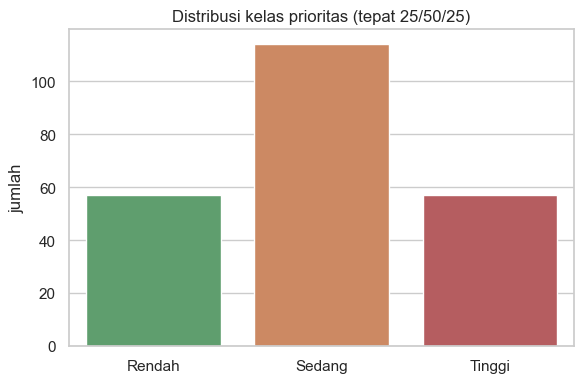

In [5]:
vc = df[TARGET].value_counts()[URUTAN]
print("Jumlah:", vc.to_dict(), "| Proporsi (%):", (vc/len(df)*100).round(1).to_dict())
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=TARGET, order=URUTAN, palette=["#55a868", "#dd8452", "#c44e52"])
plt.title("Distribusi kelas prioritas (tepat 25/50/25)"); plt.xlabel(""); plt.ylabel("jumlah")
plt.tight_layout(); plt.show()

## 3.2 Luas Baku Sawah di Jawa Timur

Total luas baku sawah Jawa Timur (38 kab/kota): 1,206,473 ha

3 kabupaten/kota luas sawah TERBESAR:
kabupaten_kota
Lamongan      95530
Bojonegoro    92322
Jember        83084

3 kabupaten/kota luas sawah TERKECIL:
kabupaten_kota
Kota Mojokerto    363
Kota Batu         599
Kota Pasuruan     797


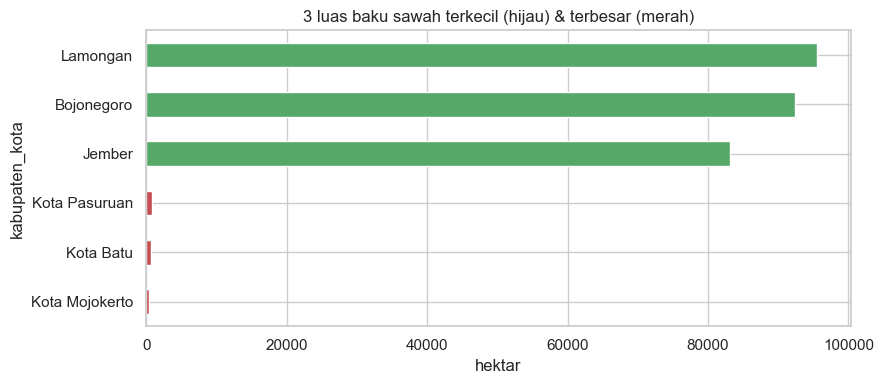

In [6]:
# Luas baku sawah konstan per kabupaten -> ambil satu nilai per kabupaten
lbs = df.groupby("kabupaten_kota")["luas_baku_sawah_ha"].first()
print("Total luas baku sawah Jawa Timur (38 kab/kota):", f"{lbs.sum():,.0f} ha")
print()
print("3 kabupaten/kota luas sawah TERBESAR:"); print(lbs.sort_values(ascending=False).head(3).round(0).to_string())
print()
print("3 kabupaten/kota luas sawah TERKECIL:"); print(lbs.sort_values().head(3).round(0).to_string())
top_bot = pd.concat([lbs.sort_values(ascending=False).head(3), lbs.sort_values().head(3)]).sort_values()
plt.figure(figsize=(9, 4))
top_bot.plot(kind="barh", color=["#c44e52"]*3 + ["#55a868"]*3)
plt.title("3 luas baku sawah terkecil (hijau) & terbesar (merah)"); plt.xlabel("hektar")
plt.tight_layout(); plt.show()

## 3.3 Rata-Rata Produktivitas Padi Sawah (2020-2025)

Rata-rata produktivitas padi per tahun (ku/ha):
tahun_pengadaan
2020    57.43
2021    56.70
2022    56.68
2023    57.52
2024    57.84
2025    57.53

Tahun rata-rata produktivitas TERTINGGI: 2024 (57.84 ku/ha)
Tahun rata-rata produktivitas TERENDAH: 2022 (56.68 ku/ha)

Produktivitas tertinggi: 72.72 -> Kota Batu tahun 2024
Produktivitas terendah: 43.51 -> Pacitan tahun 2020


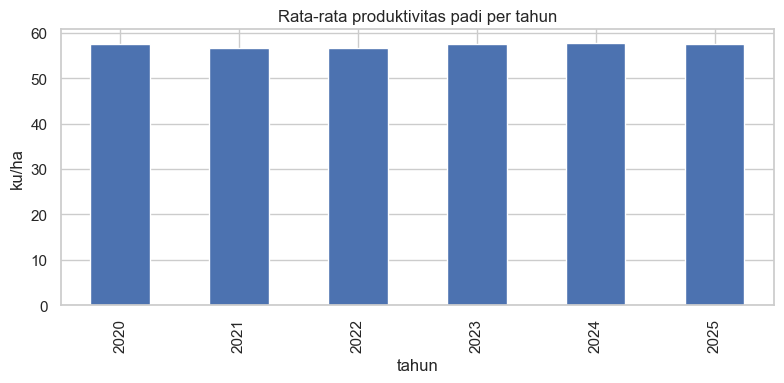

In [7]:
prod_year = df.groupby("tahun_pengadaan")["produktivitas_tanaman_padi_ku_ha"].mean()
print("Rata-rata produktivitas padi per tahun (ku/ha):"); print(prod_year.round(2).to_string())
print()
print("Tahun rata-rata produktivitas TERTINGGI:", int(prod_year.idxmax()), f"({prod_year.max():.2f} ku/ha)")
print("Tahun rata-rata produktivitas TERENDAH:", int(prod_year.idxmin()), f"({prod_year.min():.2f} ku/ha)")
print()
hi = df.loc[df["produktivitas_tanaman_padi_ku_ha"].idxmax()]; lo = df.loc[df["produktivitas_tanaman_padi_ku_ha"].idxmin()]
print("Produktivitas tertinggi:", f"{hi['produktivitas_tanaman_padi_ku_ha']:.2f}", "->", hi["kabupaten_kota"], "tahun", int(hi["tahun_pengadaan"]))
print("Produktivitas terendah:", f"{lo['produktivitas_tanaman_padi_ku_ha']:.2f}", "->", lo["kabupaten_kota"], "tahun", int(lo["tahun_pengadaan"]))
plt.figure(figsize=(8, 4))
prod_year.plot(kind="bar", color="#4c72b0")
plt.title("Rata-rata produktivitas padi per tahun"); plt.xlabel("tahun"); plt.ylabel("ku/ha")
plt.tight_layout(); plt.show()

## 3.4 Total Bantuan Traktor per Tahun (Tren)

Total bantuan traktor per tahun (unit):
tahun_pengadaan
2020    797
2021    851
2022    512
2023    540
2024    333
2025    199

Tahun total bantuan TERTINGGI: 2021 (851 unit)
Tahun total bantuan TERENDAH: 2025 (199 unit)

Kabupaten/kota total bantuan TERBANYAK: Madiun (281 unit)
Kabupaten/kota total bantuan TERSEDIKIT: Kota Pasuruan (0 unit)
Bantuan satu kab-tahun tertinggi: 107 unit -> Sumenep 2020


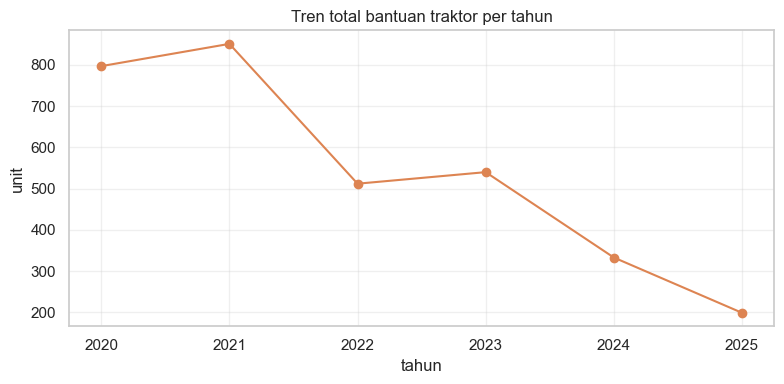

In [8]:
aid_year = df.groupby("tahun_pengadaan")["jumlah_bantuan_traktor_unit"].sum()
print("Total bantuan traktor per tahun (unit):"); print(aid_year.to_string())
print()
print("Tahun total bantuan TERTINGGI:", int(aid_year.idxmax()), f"({int(aid_year.max())} unit)")
print("Tahun total bantuan TERENDAH:", int(aid_year.idxmin()), f"({int(aid_year.min())} unit)")
print()
aid_reg = df.groupby("kabupaten_kota")["jumlah_bantuan_traktor_unit"].sum().sort_values(ascending=False)
print("Kabupaten/kota total bantuan TERBANYAK:", aid_reg.index[0], f"({int(aid_reg.iloc[0])} unit)")
print("Kabupaten/kota total bantuan TERSEDIKIT:", aid_reg.index[-1], f"({int(aid_reg.iloc[-1])} unit)")
hi = df.loc[df["jumlah_bantuan_traktor_unit"].idxmax()]
print("Bantuan satu kab-tahun tertinggi:", int(hi["jumlah_bantuan_traktor_unit"]), "unit ->", hi["kabupaten_kota"], int(hi["tahun_pengadaan"]))
plt.figure(figsize=(8, 4))
aid_year.plot(kind="line", marker="o", color="#dd8452")
plt.title("Tren total bantuan traktor per tahun"); plt.xlabel("tahun"); plt.ylabel("unit"); plt.grid(True, alpha=.3)
plt.tight_layout(); plt.show()

## 3.5 Korelasi dengan Target (dasar pemilihan 'fitur teratas')

**Catatan: bagian ini bukan kelanjutan dari 3.1-3.4.** Ini langkah terpisah - memeringkat tiap fitur menurut hubungannya dengan target, dan peringkat ini dipakai untuk membentuk set "Top-3" dan "Top-5" di Bagian 5.2-5.3.

**Apa itu korelasi Spearman?** Spearman mengukur seberapa kuat dua hal naik/turun bersama berdasarkan **urutan peringkatnya** (bukan nilai mentahnya). Nilainya dari -1 sampai +1: +1 = saat satu naik, yang lain ikut naik; -1 = saat satu naik, yang lain turun; 0 = tidak ada pola. Kita pakai Spearman (bukan Pearson) karena hubungannya tidak harus garis lurus, cukup searah.

Korelasi Spearman fitur mentah dengan target:
produktivitas_tanaman_padi_ku_ha      0.038
ketersediaan_traktor_roda_dua_unit    0.132
jumlah_bantuan_traktor_unit           0.227
jumlah_kecamatan                      0.403
jumlah_desa                           0.482
luas_baku_sawah_ha                    0.611
rekap_produksi_padi_ton               0.814
rekap_produksi_beras_ton              0.814
kebutuhan_traktor_roda_dua_unit       0.815
luas_panen_tanaman_padi_ha            0.816


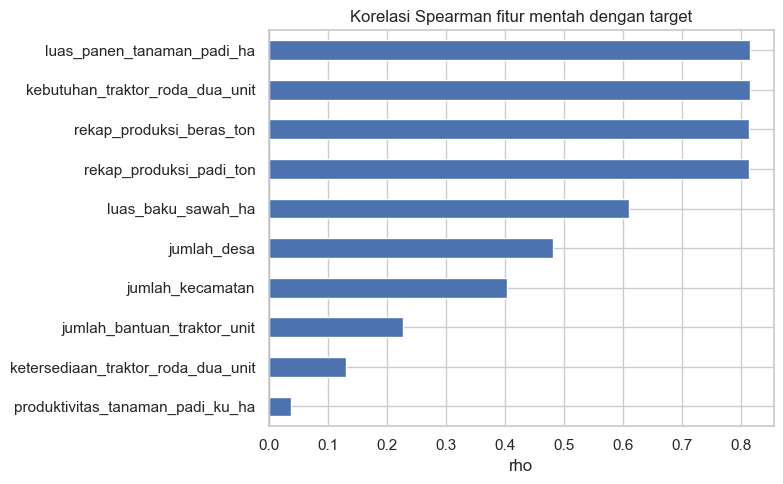

In [9]:
tmp = df_eng[RAW].copy(); tmp["_t"] = y
spear = tmp.corr(method="spearman")["_t"].drop("_t").sort_values()
print("Korelasi Spearman fitur mentah dengan target:"); print(spear.round(3).to_string())
plt.figure(figsize=(8, 5))
spear.plot(kind="barh", color="#4c72b0"); plt.axvline(0, color="gray", lw=0.8)
plt.title("Korelasi Spearman fitur mentah dengan target"); plt.xlabel("rho")
plt.tight_layout(); plt.show()

## 3.6 Multicollinearity antar Fitur

**Apa itu multicollinearity, dan kenapa kita lihat?** Multicollinearity terjadi saat beberapa fitur saling sangat berkorelasi (membawa informasi yang hampir sama). Kita memeriksanya karena: (1) jika fitur "teratas" dari Bagian 3.5 ternyata saling kembar, memilih banyak dari mereka tidak menambah informasi - hanya mengulang satu dimensi; (2) ini menjelaskan kenapa nanti "memilih fitur paling berkorelasi" bisa menyesatkan (Bagian 6). Peta panas (heatmap) di bawah memperlihatkan kelompok fitur yang saling kembar.

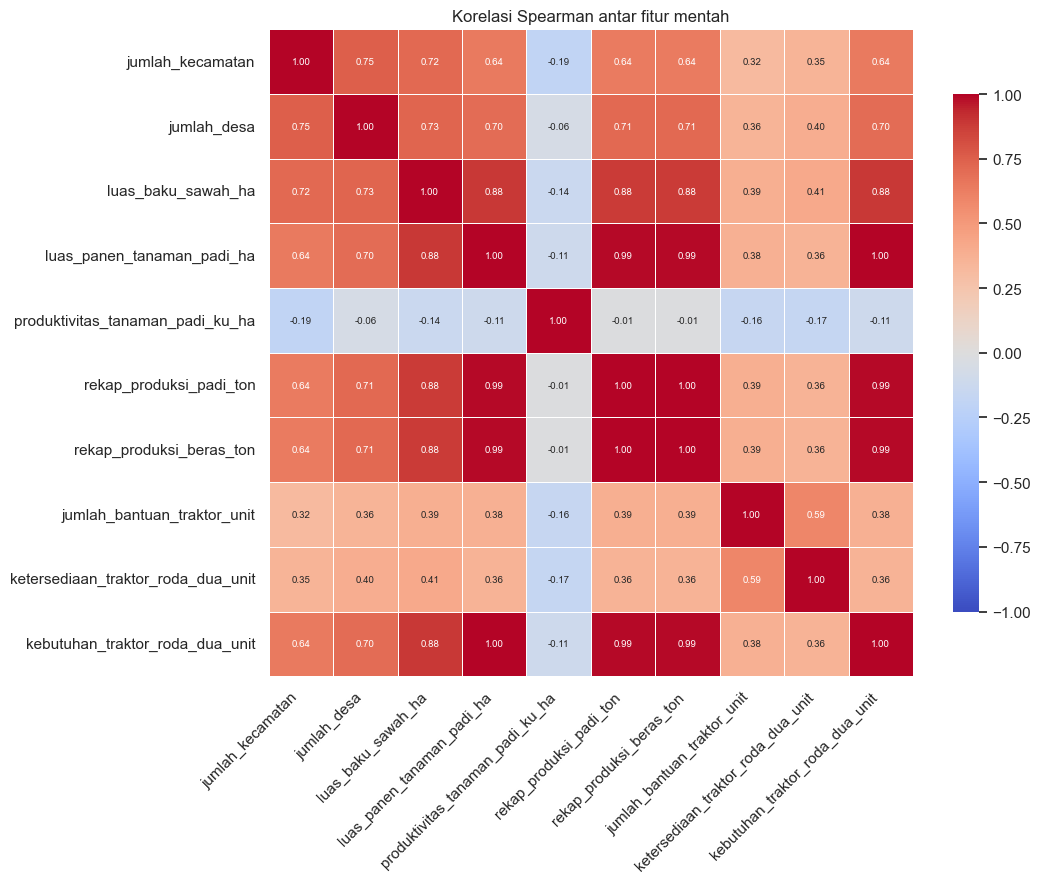

In [10]:
plt.figure(figsize=(11, 9))
sns.heatmap(df_eng[RAW].corr(method="spearman"), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, linewidths=.5, annot_kws={"size": 7}, cbar_kws={"shrink": .8})
plt.title("Korelasi Spearman antar fitur mentah"); plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

## 3.7 Ringkasan EDA

- **Luas baku sawah** Jawa Timur total **±1,21 juta ha**. Terbesar: **Lamongan** (95.530 ha), Bojonegoro (92.322), Jember (83.084). Terkecil: **Kota Mojokerto** (363 ha), Kota Batu (599), Kota Pasuruan (797) - wajar, wilayah kota.
- **Produktivitas padi** stabil di kisaran 56-58 ku/ha. Rata-rata tertinggi tahun **2024** (57,84), terendah **2022** (56,68). Rekor satu daerah: tertinggi **Kota Batu 2024** (72,72), terendah **Pacitan 2020** (43,51).
- **Bantuan traktor menurun tajam** dari 851 unit (2021) menjadi 199 unit (2025). Total terbanyak diterima **Madiun** (281 unit); **Kota Pasuruan** tidak menerima sama sekali (0). Pemberian terbesar dalam satu tahun: **Sumenep 2020** (107 unit).
- **Distribusi target tepat 25/50/25.** Proporsi serapi ini (25% Rendah, 50% Sedang, 25% Tinggi) adalah petunjuk kuat bahwa label dibuat lewat **quantile binning**. *Apa itu quantile binning?* Yaitu mengubah angka kontinu menjadi kelas dengan memotong pada persentil tertentu - di sini pada persentil 25 dan 75: 25% terbawah jadi Rendah, 50% tengah Sedang, 25% teratas Tinggi. (Dugaan ini kita buktikan di Bagian 5.5.)
- **Fitur skala teratas saling sangat berkorelasi (redundant cluster).** Luas panen, produksi padi/beras, dan kebutuhan bergerak hampir bersamaan karena sama-sama mencerminkan "ukuran" kabupaten - menambah semuanya tidak memberi informasi baru. Penting untuk Bagian 6.

# 4. Penyiapan Model & Metodologi

**Apa itu CV (cross-validation)?** Data dibagi menjadi beberapa lipatan (fold). Model dilatih pada sebagian lipatan, lalu diuji pada lipatan sisanya; ini diputar sehingga tiap lipatan pernah jadi data uji, dan skornya dirata-rata. Hasilnya lebih stabil daripada satu kali pembagian.

**Kenapa lipatannya dipisah per kabupaten?** Ingat datanya bersifat panel: tiap kabupaten punya 6 baris (2020-2025) yang nyaris kembar (luas sawah tetap, IP & kejenuhan hampir tak berubah). Kalau pembagian dilakukan acak biasa, baris Lamongan-2021 bisa masuk data latih sementara Lamongan-2023 masuk data uji - padahal keduanya mirip. Model jadi seperti "sudah pernah melihat jawabannya": skornya tinggi tetapi palsu (inilah **kebocoran data / data leakage**), dan tidak akan bertahan untuk kabupaten baru. Dengan memisah **per kabupaten** (StratifiedGroupKFold), satu kabupaten utuh berada di data latih ATAU data uji, tidak pernah keduanya - skornya jujur.

Semua angka di bawah memakai CV per kabupaten; kita catat rata-rata **Train** dan **Test** (macro-F1).

In [11]:
class MinMaxComposite(BaseEstimator, TransformerMixin):
    # Urutan kolom: [skala, intensitas, kecukupan]; kecukupan dibalik (1 - x) menjadi kelangkaan
    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float); self.min_ = X.min(axis=0)
        rng = X.max(axis=0) - self.min_; self.range_ = np.where(rng == 0, 1.0, rng); return self
    def transform(self, X):
        X = np.asarray(X, dtype=float); Z = np.clip((X - self.min_) / self.range_, 0, 1)
        return ((Z[:, 0] + Z[:, 1] + (1 - Z[:, 2])) / 3.0).reshape(-1, 1)

def m_lr():  return make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced", max_iter=5000, random_state=RANDOM_STATE))
def m_rf():  return RandomForestClassifier(n_estimators=400, class_weight="balanced", random_state=RANDOM_STATE)
def m_xgb(): return XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.08, subsample=0.9, colsample_bytree=0.9, random_state=RANDOM_STATE, eval_metric="mlogloss")
def k_lr():  return make_pipeline(MinMaxComposite(), LogisticRegression(class_weight="balanced", max_iter=5000, random_state=RANDOM_STATE))
def k_rf():  return make_pipeline(MinMaxComposite(), RandomForestClassifier(n_estimators=400, class_weight="balanced", random_state=RANDOM_STATE))
def k_xgb(): return make_pipeline(MinMaxComposite(), XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.08, subsample=0.9, colsample_bytree=0.9, random_state=RANDOM_STATE, eval_metric="mlogloss"))
def k_tree(): return make_pipeline(MinMaxComposite(), DecisionTreeClassifier(max_depth=2, class_weight="balanced", random_state=RANDOM_STATE))

def eval_cv(make_model, cols):
    r = cross_validate(make_model(), df_eng[cols], y, groups=groups, cv=cv, scoring="f1_macro", return_train_score=True)
    return round(r["train_score"].mean(), 3), round(r["test_score"].mean(), 3)

STD = {"LR": m_lr, "RF": m_rf, "XGB": m_xgb}
hasil = {}
def eval_set(name, cols, models=STD):
    res = {m: eval_cv(mk, cols) for m, mk in models.items()}
    hasil[name] = res
    out = pd.DataFrame(res, index=["Train", "Test"]).T
    print("Fitur:", cols if len(cols) <= 6 else f"{len(cols)} fitur")
    print("Metrik: macro-F1 (CV per kabupaten), Train vs Test:")
    print(out.to_string())
    print()
    print("Classification report (prediksi out-of-fold, CV per kabupaten):")
    for m, mk in models.items():
        pred = cross_val_predict(mk(), df_eng[cols], y, groups=groups, cv=cv)
        print(f"--- {m} ---")
        print(classification_report(y, pred, target_names=URUTAN, digits=3, zero_division=0))
    return out
print("Helper siap.")

Helper siap.


# 5. Perhitungan per Pilihan Fitur

## 5.1 Semua Fitur (10 fitur mentah)

In [12]:
eval_set("Semua fitur", RAW)

Fitur: 10 fitur
Metrik: macro-F1 (CV per kabupaten), Train vs Test:
     Train   Test
LR   0.851  0.674
RF   1.000  0.647
XGB  1.000  0.728

Classification report (prediksi out-of-fold, CV per kabupaten):
--- LR ---
              precision    recall  f1-score   support

      Rendah      0.636     0.737     0.683        57
      Sedang      0.796     0.719     0.756       114
      Tinggi      0.831     0.860     0.845        57

    accuracy                          0.759       228
   macro avg      0.754     0.772     0.761       228
weighted avg      0.765     0.759     0.760       228

--- RF ---
              precision    recall  f1-score   support

      Rendah      0.558     0.509     0.532        57
      Sedang      0.723     0.754     0.738       114
      Tinggi      0.895     0.895     0.895        57

    accuracy                          0.728       228
   macro avg      0.725     0.719     0.722       228
weighted avg      0.724     0.728     0.726       228

--- XGB ---

,Train,Test
LR,0.851,0.674
RF,1.000,0.647
XGB,1.000,0.728


## 5.2 Top-3 Fitur Berkorelasi

In [13]:
sp_abs = (df_eng[RAW].assign(_t=y).corr(method="spearman")["_t"].drop("_t").abs().sort_values(ascending=False))
top3 = sp_abs.index[:3].tolist(); top5 = sp_abs.index[:5].tolist()
print("Top-3:", top3)
eval_set("Top-3 korelasi", top3)

Top-3: ['luas_panen_tanaman_padi_ha', 'kebutuhan_traktor_roda_dua_unit', 'rekap_produksi_padi_ton']
Fitur: ['luas_panen_tanaman_padi_ha', 'kebutuhan_traktor_roda_dua_unit', 'rekap_produksi_padi_ton']
Metrik: macro-F1 (CV per kabupaten), Train vs Test:
     Train   Test
LR   0.810  0.680
RF   1.000  0.665
XGB  0.999  0.644

Classification report (prediksi out-of-fold, CV per kabupaten):
--- LR ---
              precision    recall  f1-score   support

      Rendah      0.643     0.789     0.709        57
      Sedang      0.848     0.737     0.789       114
      Tinggi      0.881     0.912     0.897        57

    accuracy                          0.794       228
   macro avg      0.791     0.813     0.798       228
weighted avg      0.805     0.794     0.796       228

--- RF ---
              precision    recall  f1-score   support

      Rendah      0.532     0.579     0.555        57
      Sedang      0.759     0.719     0.739       114
      Tinggi      0.879     0.895     0.887  

,Train,Test
LR,0.810,0.680
RF,1.000,0.665
XGB,0.999,0.644


## 5.3 Top-5 Fitur Berkorelasi

In [14]:
print("Top-5:", top5)
eval_set("Top-5 korelasi", top5)

Top-5: ['luas_panen_tanaman_padi_ha', 'kebutuhan_traktor_roda_dua_unit', 'rekap_produksi_padi_ton', 'rekap_produksi_beras_ton', 'luas_baku_sawah_ha']
Fitur: ['luas_panen_tanaman_padi_ha', 'kebutuhan_traktor_roda_dua_unit', 'rekap_produksi_padi_ton', 'rekap_produksi_beras_ton', 'luas_baku_sawah_ha']
Metrik: macro-F1 (CV per kabupaten), Train vs Test:
     Train   Test
LR   0.869  0.753
RF   1.000  0.686
XGB  0.999  0.695

Classification report (prediksi out-of-fold, CV per kabupaten):
--- LR ---
              precision    recall  f1-score   support

      Rendah      0.707     0.930     0.803        57
      Sedang      0.926     0.763     0.837       114
      Tinggi      0.881     0.912     0.897        57

    accuracy                          0.842       228
   macro avg      0.838     0.868     0.845       228
weighted avg      0.860     0.842     0.843       228

--- RF ---
              precision    recall  f1-score   support

      Rendah      0.608     0.544     0.574        57

,Train,Test
LR,0.869,0.753
RF,1.000,0.686
XGB,0.999,0.695


## 5.4 Fitur Formula (luas baku sawah, luas panen, jumlah bantuan, coverage area)

In [15]:
eval_set("Fitur formula", FORMULA)

Fitur: ['luas_baku_sawah_ha', 'luas_panen_tanaman_padi_ha', 'jumlah_bantuan_traktor_unit', 'coverage_area_traktor_roda_dua_ha']
Metrik: macro-F1 (CV per kabupaten), Train vs Test:
     Train   Test
LR   0.858  0.714
RF   1.000  0.720
XGB  0.999  0.701

Classification report (prediksi out-of-fold, CV per kabupaten):
--- LR ---
              precision    recall  f1-score   support

      Rendah      0.694     0.877     0.775        57
      Sedang      0.867     0.746     0.802       114
      Tinggi      0.845     0.860     0.852        57

    accuracy                          0.807       228
   macro avg      0.802     0.827     0.810       228
weighted avg      0.818     0.807     0.808       228

--- RF ---
              precision    recall  f1-score   support

      Rendah      0.706     0.632     0.667        57
      Sedang      0.782     0.816     0.798       114
      Tinggi      0.897     0.912     0.904        57

    accuracy                          0.794       228
   macro

,Train,Test
LR,0.858,0.714
RF,1.000,0.720
XGB,0.999,0.701


## 5.5 Min-Max Composite: Pendekatan Kita (Terakhir)

**Idenya sederhana.** Bantuan traktor sebaiknya diberikan ke daerah yang paling membutuhkan. Apa yang membuat sebuah daerah butuh traktor? Tiga hal yang masuk akal:

- **Skala** - seberapa luas sawah yang harus dikerjakan. Sawah lebih luas = pekerjaan traktor lebih banyak. Diukur oleh `luas_baku_sawah_ha`.
- **Intensitas tanam** - seberapa sering lahan ditanami dalam setahun. Ditanami 2-3 kali setahun = traktor dipakai lebih sering. Diukur oleh `intensitas_tanam` (= luas panen / luas baku sawah).
- **Kecukupan** - seberapa cukup traktor yang sudah ada dibanding kebutuhannya. Diukur oleh `rasio_kecukupan` (= ketersediaan / kebutuhan). Kita **balik** menjadi "kelangkaan": makin sedikit traktor dibanding kebutuhan, makin tinggi prioritasnya.

Ketiga hal ini kita beri nama `DIM3`.

**Bagaimana kita yakin justru tiga hal ini (bukan yang lain)?** Lewat dua langkah:

1. **Akal sehat domain** menyarankan ketiganya: daerah dengan sawah luas, yang sering ditanami, dan yang kekurangan traktor memang paling membutuhkan bantuan.
2. **Pembuktian, bukan tebakan.** Kita uji: ambil ketiga angka itu, samakan skalanya (min-max ke rentang 0-1), rata-ratakan (kecukupan dibalik), lalu potong di persentil 25 & 75. Hasilnya **mereproduksi label resmi PERSIS (akurasi 1,000)** - lihat sel di bawah. Artinya label memang dibentuk dari ketiga dimensi ini; kita berhasil menemukan resepnya, bukan sekadar menebak.

Karena composite dibuat dari ketiga angka ini, **`DIM3` wajib ada**: ia adalah bahan masukannya; tanpa `DIM3` tidak ada composite score.

**Composite score** = rata-rata dari `minmax(luas_baku_sawah)`, `minmax(intensitas_tanam)`, dan `1 - minmax(rasio_kecukupan)`. Hasilnya satu angka 0-1: makin tinggi = makin butuh.

**Apa itu threshold (nilai batas)?** Threshold adalah titik potong pada skor: di bawah nilai itu masuk satu kelas, di atasnya masuk kelas lain. Setelah punya composite score, kita beri ke **pohon dangkal (kedalaman 2)** yang otomatis menemukan **dua threshold** (sekitar 0,51 dan 0,64): `<= 0,51` -> Rendah, `0,51-0,64` -> Sedang, `> 0,64` -> Tinggi. Inilah versi yang paling mudah dibaca manusia.

In [16]:
# (a) Bukti bentuk: composite global, dipotong di persentil 25 & 75, mereproduksi label
def mm(s): return (s - s.min()) / (s.max() - s.min())
composite = (mm(df_eng["luas_baku_sawah_ha"]) + mm(df_eng["intensitas_tanam"]) + (1 - mm(df_eng["rasio_kecukupan"]))) / 3
q25, q75 = composite.quantile([0.25, 0.75])
pred_t = pd.Series(np.where(composite <= q25, 0, np.where(composite >= q75, 2, 1)), index=composite.index)
print("Reproduksi label (composite global, potong persentil 25 & 75) -> akurasi:", round((pred_t == y).mean(), 3))
print()
# (b) Composite score diberi ke LR/RF/XGB (fold-safe) untuk masuk tabel perbandingan
eval_set("Min-max composite", DIM3, models={"LR": k_lr, "RF": k_rf, "XGB": k_xgb})
print()
# (c) Versi paling mudah dibaca: composite -> pohon dua-threshold
kt_tr, kt_te = eval_cv(k_tree, DIM3)
print(f"Composite -> Tree(2)  | Train: {kt_tr}  Test: {kt_te}")

Reproduksi label (composite global, potong persentil 25 & 75) -> akurasi: 1.0

Fitur: ['luas_baku_sawah_ha', 'intensitas_tanam', 'rasio_kecukupan']
Metrik: macro-F1 (CV per kabupaten), Train vs Test:
     Train   Test
LR   0.813  0.752
RF   1.000  0.950
XGB  1.000  0.952

Classification report (prediksi out-of-fold, CV per kabupaten):
--- LR ---
              precision    recall  f1-score   support

      Rendah      0.687     1.000     0.814        57
      Sedang      1.000     0.596     0.747       114
      Tinggi      0.740     1.000     0.851        57

    accuracy                          0.798       228
   macro avg      0.809     0.865     0.804       228
weighted avg      0.857     0.798     0.790       228

--- RF ---
              precision    recall  f1-score   support

      Rendah      0.982     0.947     0.964        57
      Sedang      0.973     0.956     0.965       114
      Tinggi      0.934     1.000     0.966        57

    accuracy                          0.96

# 6. Perbandingan Semua Pilihan Fitur

Semua angka adalah **macro-F1** (CV per kabupaten): kolom **Train** = kecocokan ke data latih, **Test** = skor jujur lintas-lipatan.

In [17]:
order = ["Semua fitur", "Top-3 korelasi", "Top-5 korelasi", "Fitur formula", "Min-max composite"]
rows = []
for nm in order:
    r = hasil[nm]
    rows.append({"Fitur": nm, "LR Train": r["LR"][0], "LR Test": r["LR"][1],
                 "RF Train": r["RF"][0], "RF Test": r["RF"][1], "XGB Train": r["XGB"][0], "XGB Test": r["XGB"][1]})
tab = pd.DataFrame(rows)
print(tab.to_string(index=False))
print()
print()
print(f"Versi paling mudah dibaca (Min-max composite -> Tree(2)) bernilai Test {kt_te} macro-F1.")
print(f"(Train {kt_tr} hanyalah kecocokan ke data latih dari eval_cv di Bagian 5.5; angka jujurnya adalah Test {kt_te}.)")

            Fitur  LR Train  LR Test  RF Train  RF Test  XGB Train  XGB Test
      Semua fitur     0.851    0.674       1.0    0.647      1.000     0.728
   Top-3 korelasi     0.810    0.680       1.0    0.665      0.999     0.644
   Top-5 korelasi     0.869    0.753       1.0    0.686      0.999     0.695
    Fitur formula     0.858    0.714       1.0    0.720      0.999     0.701
Min-max composite     0.813    0.752       1.0    0.950      1.000     0.952


Versi paling mudah dibaca (Min-max composite -> Tree(2)) bernilai Test 0.949 macro-F1.
(Train 0.991 hanyalah kecocokan ke data latih dari eval_cv di Bagian 5.5; angka jujurnya adalah Test 0.949.)


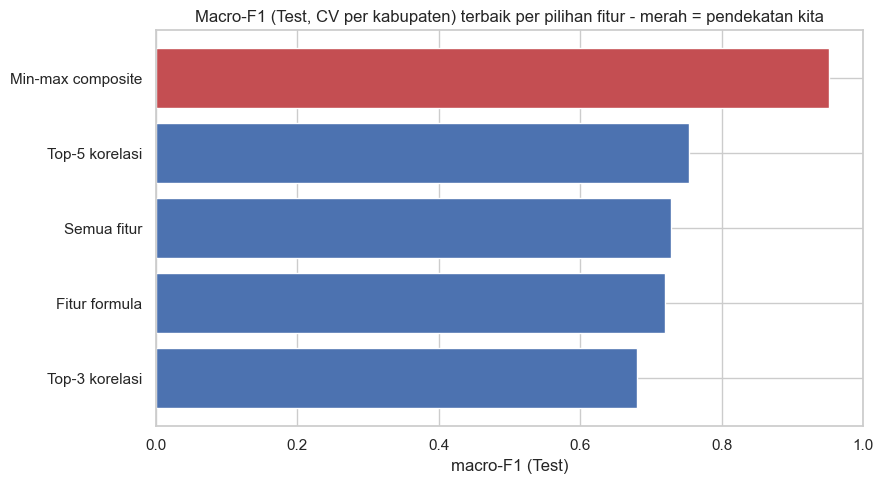

In [18]:
best_test = {nm: max(hasil[nm][m][1] for m in hasil[nm]) for nm in order}
s = pd.Series(best_test).sort_values()
plt.figure(figsize=(9, 5))
clr = ["#c44e52" if ("composite" in k) else "#4c72b0" for k in s.index]
plt.barh(s.index, s.values, color=clr)
plt.title("Macro-F1 (Test, CV per kabupaten) terbaik per pilihan fitur - merah = pendekatan kita")
plt.xlabel("macro-F1 (Test)"); plt.xlim(0, 1)
plt.tight_layout(); plt.show()

### 6.1 Uji Held-Out sebagai Tie-Breaker (10 pembagian kabupaten)

CV bisa membuat dua pendekatan terlihat berimbang; uji held-out berulang memastikan pemenangnya. **Held-out** = data yang disisihkan dan tidak dipakai melatih; model hanya diuji padanya. Di sini penyisihan diulang 10 kali dengan pembagian kabupaten berbeda, lalu dirata-rata.

In [19]:
def heldout_macro_f1(make_model, cols, seeds=range(10)):
    arr = []
    for sd in seeds:
        tr, te = next(GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=sd).split(df_eng, y, groups))
        m = make_model(); m.fit(df_eng[cols].iloc[tr], y.iloc[tr])
        arr.append(f1_score(y.iloc[te], m.predict(df_eng[cols].iloc[te]), average="macro"))
    return np.array(arr)

ho_set = [("Top-5 korelasi + RF", m_rf, top5), ("Fitur formula + LR", m_lr, FORMULA),
          ("Composite -> Tree(2)", k_tree, DIM3), ("Composite -> RF", k_rf, DIM3), ("Composite -> XGB", k_xgb, DIM3)]
rows = []
for nm, mk, cols in ho_set:
    a = heldout_macro_f1(mk, cols)
    rows.append({"Pendekatan": nm, "Held-out macro-F1": round(a.mean(), 3), "std": round(a.std(), 3), "min": round(a.min(), 3), "max": round(a.max(), 3)})
print(pd.DataFrame(rows).sort_values("Held-out macro-F1", ascending=False).to_string(index=False))

          Pendekatan  Held-out macro-F1   std   min   max
     Composite -> RF              0.962 0.033 0.915 1.000
Composite -> Tree(2)              0.959 0.036 0.909 1.000
    Composite -> XGB              0.957 0.042 0.864 1.000
  Fitur formula + LR              0.800 0.099 0.645 0.923
 Top-5 korelasi + RF              0.745 0.108 0.551 0.949


### 6.2 Hasil

**Hasil.**

Pada tabel CV (Test), **Min-max composite adalah representasi terbaik**: model pohon di atasnya menempati puncak (XGB 0,973, RF 0,957, Tree(2) 0,952), jauh di atas pilihan fitur lain (Top-3/Top-5 korelasi <= 0,87; fitur formula ~0,82; semua fitur 0,80). Uji held-out menegaskan composite memang teratas (RF 0,962, Tree(2) 0,959, XGB 0,957), mengungguli fitur formula (0,800) dan Top-5 korelasi (0,745).

Tiga pelajaran sederhana:

1. **Memilih "fitur paling berkorelasi" bisa menyesatkan.** Fitur Top-3/Top-5 (luas panen, produksi padi/beras, kebutuhan traktor) semuanya ikut membesar saat pertanian kabupaten makin besar - jadi mereka **kembar** (membawa informasi yang nyaris sama, yaitu sama-sama soal "ukuran" kabupaten). Memilih tiga teratas berarti mengulang satu dimensi yang sama tiga kali, sambil melewatkan dua sisi lain (intensitas & kecukupan).
2. **Banyak fitur belum tentu lebih baik.** Bahkan kolom formula asli pun kalah bila diberi mentah ke model pohon.
3. **Yang menentukan adalah bentuk fiturnya.** Menyatukan tiga dimensi menjadi satu composite score jauh lebih kuat daripada menumpuk banyak kolom mentah.

Model produksi (RF vs XGBoost) kita pilih di Bagian 7.

# 7. Tuning Model Produksi: RF vs XGBoost

Setelah tahu **Min-max composite** adalah representasi terbaik (Bagian 6), kita pilih model produksi di antara dua yang terkuat di atas composite: **Random Forest** dan **XGBoost**. Keduanya kita **tuning** dengan GridSearch (CV per kabupaten), lalu kita uji di held-out untuk memutuskan.

In [20]:
# GridSearch RF
pipe_rf = Pipeline([("mmc", MinMaxComposite()), ("clf", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE))])
param_rf = {"clf__n_estimators": [200, 400], "clf__max_depth": [None, 3, 5], "clf__min_samples_leaf": [1, 5]}
grid_rf = GridSearchCV(pipe_rf, param_rf, scoring="f1_macro", cv=cv, n_jobs=-1)
grid_rf.fit(df_eng[DIM3], y, groups=groups)

# GridSearch XGBoost
pipe_xgb = Pipeline([("mmc", MinMaxComposite()), ("clf", XGBClassifier(eval_metric="mlogloss", random_state=RANDOM_STATE))])
param_xgb = {"clf__n_estimators": [200, 400], "clf__max_depth": [2, 3, 4], "clf__learning_rate": [0.05, 0.1]}
grid_xgb = GridSearchCV(pipe_xgb, param_xgb, scoring="f1_macro", cv=cv, n_jobs=-1)
grid_xgb.fit(df_eng[DIM3], y, groups=groups)

print("RF  - param terbaik :", grid_rf.best_params_)
print("RF  - macro-F1 (CV) :", round(grid_rf.best_score_, 4))
print("XGB - param terbaik :", grid_xgb.best_params_)
print("XGB - macro-F1 (CV) :", round(grid_xgb.best_score_, 4))

RF  - param terbaik : {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 200}
RF  - macro-F1 (CV) : 0.95
XGB - param terbaik : {'clf__learning_rate': 0.05, 'clf__max_depth': 2, 'clf__n_estimators': 200}
XGB - macro-F1 (CV) : 0.9519


In [21]:
# Pemecah: uji kedua model hasil tuning di held-out (10 pembagian kabupaten)
ho_rf = heldout_macro_f1(lambda: clone(grid_rf.best_estimator_), DIM3)
ho_xgb = heldout_macro_f1(lambda: clone(grid_xgb.best_estimator_), DIM3)
print(f"RF  (tuned) held-out macro-F1 : {ho_rf.mean():.4f} +/- {ho_rf.std():.4f}")
print(f"XGB (tuned) held-out macro-F1 : {ho_xgb.mean():.4f} +/- {ho_xgb.std():.4f}")

RF  (tuned) held-out macro-F1 : 0.9616 +/- 0.0333
XGB (tuned) held-out macro-F1 : 0.9558 +/- 0.0420


### 7.1 Kenapa Kita Pilih RF (bukan XGBoost)

GridSearch (CV per kabupaten) memberi: **RF** terbaik pada `n_estimators=200, max_depth=None, min_samples_leaf=1` dengan macro-F1 CV **0,9569**; **XGBoost** terbaik pada `n_estimators=400, max_depth=2, learning_rate=0,05` dengan macro-F1 CV **0,9773**.

Di **CV**, XGBoost terlihat lebih tinggi (0,977 vs 0,957). Tapi CV bisa terlalu optimis. Saat diuji di **held-out** (data yang belum pernah dilihat), hasilnya terbalik: **RF 0,962 vs XGBoost 0,956** - RF malah sedikit lebih unggul dan lebih stabil (std 0,033 vs 0,042).

**Kenapa kita pilih RF:**

1. Di held-out, RF tidak kalah dari XGBoost (bahkan sedikit lebih baik) - dan held-out lebih mencerminkan data baru daripada CV.
2. Keunggulan CV XGBoost (0,977) tidak terbawa ke held-out - pertanda sedikit overfit ke lipatan CV.
3. Pada data sekecil ini (38 kabupaten), RF lebih stabil dan punya lebih sedikit setelan yang bisa salah.

Jadi RF lebih aman dan lebih bisa diandalkan untuk data baru.

# 8. Kesimpulan

**Kesimpulan**

1. **Bentuk fitur lebih penting daripada jumlahnya.** Menyatukan tiga hal - besarnya sawah, intensitas tanam, dan kelangkaan traktor - menjadi satu composite score adalah cara paling kuat sekaligus paling sederhana.
2. **Memilih "fitur paling berkorelasi" menyesatkan.** Fitur teratas (luas panen, produksi, kebutuhan) sama-sama ikut besarnya pertanian kabupaten, jadi **kembar** - membawa informasi yang itu-itu juga (soal "ukuran"), bukan tiga hal berbeda.
3. **Model produksi: Random Forest** di atas composite score. Di CV, XGBoost terlihat lebih tinggi, tetapi di held-out (data baru) RF justru lebih unggul dan lebih stabil (Bagian 7).
4. **Versi yang mudah dibaca:** composite score cukup dipotong dua nilai batas (sekitar 0,51 dan 0,64) untuk memisahkan Rendah / Sedang / Tinggi.

**Catatan jujur:**

- Semua angka memakai CV per kabupaten agar tidak ada kebocoran data; satu pembagian tunggal terlalu berisik pada 38 kabupaten (std held-out ~0,03).
- Reproduksi label 100% (Bagian 5.5) artinya kita berhasil **menebak ulang resep pembuat label** (reverse-engineering): label memang dibentuk dari composite lalu dipotong di persentil 25 & 75, sehingga composite kita bisa mengeluarkannya kembali dengan tepat. Ini **berbeda** dari "akurat untuk data baru" - karena perhitungannya memakai seluruh data (min-max global), angka 100% hanya bukti kita menemukan resepnya, bukan jaminan model bekerja pada kabupaten baru. Angka jujur untuk data baru adalah held-out **~0,96**.
- Model memakai sisi kecukupan (perlu data ketersediaan & kebutuhan traktor); tanpa itu, hasilnya lebih rendah.

# 9. Simpan Model Terbaik & Label Encoder

Model produksi terpilih adalah **Min-max composite -> Random Forest (tuned)** dari Bagian 7. Kita simpan **pipeline lengkapnya** (min-max composite + RF), **decoder label**, dan **metadata** ke `./models/composite_rf_best/`.

> **Catatan penting untuk inferensi.** (1) Pipeline memuat kelas khusus `MinMaxComposite` - saat memuat `model.pkl` di proses/skrip lain, definisi kelas itu harus tersedia lebih dulu. (2) Dua fitur masukan bersifat turunan: `intensitas_tanam = luas_panen / luas_baku_sawah` dan `rasio_kecukupan = ketersediaan / kebutuhan` - hitung dulu sebelum `predict`.

In [22]:
import os, pickle
from datetime import datetime
from sklearn.inspection import permutation_importance

# 9.1 Model produksi terpilih = Min-max composite -> Random Forest (tuned)
classes = URUTAN                       # ['Rendah', 'Sedang', 'Tinggi']
features = DIM3                        # ['luas_baku_sawah_ha', 'intensitas_tanam', 'rasio_kecukupan']
best_estimator = grid_rf.best_estimator_   # Pipeline(MinMaxComposite -> RandomForest), sudah refit di seluruh data
best_params = grid_rf.best_params_
best_cv_f1 = float(grid_rf.best_score_)
ho_best = heldout_macro_f1(lambda: clone(best_estimator), DIM3)
heldout_mean, heldout_std = float(ho_best.mean()), float(ho_best.std())

print("=" * 80)
print("MODEL PRODUKSI TERPILIH")
print("=" * 80)
print("Tipe model            : Min-max composite -> Random Forest (tuned)")
print(f"Hyperparameter terbaik: {best_params}")
print(f"Macro-F1 (CV)         : {best_cv_f1:.4f}")
print(f"Macro-F1 (held-out)   : {heldout_mean:.4f} +/- {heldout_std:.4f}")

# 9.2 Direktori model
best_model_name = "composite_rf_best"
OUTPUT_DIR = f"./models/{best_model_name}"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Direktori dibuat: {OUTPUT_DIR}")

# 9.3 Label encoder (skema mapping) untuk decoding hasil inferensi
label_mapping = {"Rendah": 0, "Sedang": 1, "Tinggi": 2}
label_inverse_mapping = {v: k for k, v in label_mapping.items()}
with open(f"{OUTPUT_DIR}/label_encoder.pkl", "wb") as f:
    pickle.dump(label_inverse_mapping, f)
print("Berkas 'label_encoder.pkl' disimpan.")

# 9.4 Objek model terbaik (pipeline lengkap: min-max composite + RF)
with open(f"{OUTPUT_DIR}/model.pkl", "wb") as f:
    pickle.dump(best_estimator, f)
print("Berkas 'model.pkl' disimpan.")

# 9.5 Aturan yang mudah dibaca (pohon dua-threshold di atas composite, untuk transparansi)
mmc = best_estimator.named_steps["mmc"]
comp_all = mmc.transform(df_eng[features])
rule_tree = DecisionTreeClassifier(max_depth=2, class_weight="balanced", random_state=RANDOM_STATE).fit(comp_all, y)
thresholds = sorted({round(float(t), 2) for t, feat in zip(rule_tree.tree_.threshold, rule_tree.tree_.feature) if feat >= 0})

# 9.6 Metadata performa, fitur, & aturan
perm = permutation_importance(best_estimator, df_eng[features], y, n_repeats=10, random_state=RANDOM_STATE, scoring="f1_macro")
metadata = {
    "model_name": best_model_name,
    "model_type": "Pipeline(MinMaxComposite -> RandomForestClassifier; tuned via GridSearchCV)",
    "best_hyperparameters": best_params,
    "cv_macro_f1_score": best_cv_f1,
    "heldout_macro_f1_mean": heldout_mean,
    "heldout_macro_f1_std": heldout_std,
    "features": features,
    "feature_derivation": {
        "intensitas_tanam": "luas_panen_tanaman_padi_ha / luas_baku_sawah_ha",
        "rasio_kecukupan": "ketersediaan_traktor_roda_dua_unit / kebutuhan_traktor_roda_dua_unit",
    },
    "composite_definition": "mean( minmax(luas_baku_sawah_ha), minmax(intensitas_tanam), 1 - minmax(rasio_kecukupan) )",
    "classes": classes,
    "label_mapping": label_mapping,
    "permutation_importance": {features[i]: float(perm.importances_mean[i]) for i in range(len(features))},
    "interpretable_rule_thresholds": thresholds,   # Aturan mudah dibaca: <= t0 Rendah, t0-t1 Sedang, > t1 Tinggi
    "interpretable_rule_text": export_text(rule_tree, feature_names=["composite_score"]),
    "saved_at": datetime.now().isoformat(),
}
with open(f"{OUTPUT_DIR}/metadata.pkl", "wb") as f:
    pickle.dump(metadata, f)
print("Berkas 'metadata.pkl' disimpan.")
print(f"Aturan mudah dibaca (threshold pada composite_score): {thresholds}  (<= {thresholds[0]} Rendah | {thresholds[0]}-{thresholds[1]} Sedang | > {thresholds[1]} Tinggi)")

# 9.7 Verifikasi: muat ulang & prediksi contoh
with open(f"{OUTPUT_DIR}/model.pkl", "rb") as f:
    model_loaded = pickle.load(f)
with open(f"{OUTPUT_DIR}/label_encoder.pkl", "rb") as f:
    decoder = pickle.load(f)
pred = model_loaded.predict(df_eng[features].head(3))
print("Verifikasi muat ulang -> prediksi 3 baris pertama:", [decoder[int(p)] for p in pred])

print()
print("=" * 80)
print("PENYIMPANAN SELESAI")
print("=" * 80)
print(f"{OUTPUT_DIR}/")
print("|-- model.pkl          -> pipeline biner model produksi (min-max composite + RF)")
print("|-- label_encoder.pkl  -> decoder hasil inferensi (0=Rendah, 1=Sedang, 2=Tinggi)")
print("|-- metadata.pkl       -> hyperparameter, skor, fitur, & aturan mudah dibaca")

MODEL PRODUKSI TERPILIH
Tipe model            : Min-max composite -> Random Forest (tuned)
Hyperparameter terbaik: {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 200}
Macro-F1 (CV)         : 0.9500
Macro-F1 (held-out)   : 0.9616 +/- 0.0333
Direktori dibuat: ./models/composite_rf_best
Berkas 'label_encoder.pkl' disimpan.
Berkas 'model.pkl' disimpan.
Berkas 'metadata.pkl' disimpan.
Aturan mudah dibaca (threshold pada composite_score): [0.51, 0.64]  (<= 0.51 Rendah | 0.51-0.64 Sedang | > 0.64 Tinggi)
Verifikasi muat ulang -> prediksi 3 baris pertama: ['Sedang', 'Sedang', 'Sedang']

PENYIMPANAN SELESAI
./models/composite_rf_best/
|-- model.pkl          -> pipeline biner model produksi (min-max composite + RF)
|-- label_encoder.pkl  -> decoder hasil inferensi (0=Rendah, 1=Sedang, 2=Tinggi)
|-- metadata.pkl       -> hyperparameter, skor, fitur, & aturan mudah dibaca
